# DefectVision — 03 Data Preprocessing & Segmentation Pipeline

This notebook converts the verified raw images and masks into a reproducible PyTorch segmentation pipeline.

## Goals
- Keep the supplied train/validation/test split unchanged
- Use the existing 256×256 resolution
- Convert masks into binary defect masks
- Apply augmentation **only to training data**
- Apply deterministic preprocessing to validation/test data
- Build PyTorch `Dataset` and `DataLoader` objects
- Verify image/mask alignment after transformations
- Inspect a batch before model training

**Important:** Raw files are never modified.


## 1. Imports and configuration


In [1]:
from pathlib import Path
import random

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

PROJECT_ROOT = Path.cwd().resolve().parent
DATA_ROOT = PROJECT_ROOT / "data" / "raw" / "MVTecAD-SEG"

IMG_ROOT = DATA_ROOT / "imgs"
ANN_ROOT = DATA_ROOT / "annotations"

IMAGE_SIZE = 256
BATCH_SIZE = 16
NUM_WORKERS = 0

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Project root:", PROJECT_ROOT)
print("Dataset root:", DATA_ROOT)
print("Device:", DEVICE)


Project root: C:\Documents\DefectVision
Dataset root: C:\Documents\DefectVision\data\raw\MVTecAD-SEG
Device: cpu


## 2. Reproducibility


In [2]:
def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

generator = torch.Generator()
generator.manual_seed(SEED)


## 3. Why this preprocessing strategy?

The EDA showed:

- All images are already **256×256 RGB**
- Every image has a paired segmentation annotation
- Train/validation/test have **0 ID overlap**
- Defect size varies substantially
- Some images contain multiple disconnected defect regions

Therefore:

- **No random re-splitting**
- **No unnecessary resizing**
- Training gets geometric augmentation
- Validation/test remain deterministic
- Masks use nearest-neighbor interpolation
- Masks are converted to binary `{0,1}` targets


## 4. Dataset class


In [3]:
class DefectSegmentationDataset(Dataset):
    def __init__(self, split, augment=False):
        self.split = split
        self.augment = augment

        self.img_dir = IMG_ROOT / split
        self.mask_dir = ANN_ROOT / split

        self.image_paths = sorted(self.img_dir.glob("*.png"))

        if not self.image_paths:
            raise RuntimeError(f"No PNG images found in {self.img_dir}")

        missing = [
            p.name for p in self.image_paths
            if not (self.mask_dir / p.name).exists()
        ]

        if missing:
            raise RuntimeError(
                f"{split}: {len(missing)} images have no matching mask. "
                f"Examples: {missing[:5]}"
            )

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        mask_path = self.mask_dir / image_path.name

        image = Image.open(image_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        if image.size != (IMAGE_SIZE, IMAGE_SIZE):
            image = image.resize(
                (IMAGE_SIZE, IMAGE_SIZE),
                Image.Resampling.BILINEAR
            )

        if mask.size != (IMAGE_SIZE, IMAGE_SIZE):
            mask = mask.resize(
                (IMAGE_SIZE, IMAGE_SIZE),
                Image.Resampling.NEAREST
            )

        # Apply exactly the same geometric transform to image and mask.
        if self.augment:
            if random.random() < 0.5:
                image = image.transpose(Image.Transpose.FLIP_LEFT_RIGHT)
                mask = mask.transpose(Image.Transpose.FLIP_LEFT_RIGHT)

            if random.random() < 0.5:
                image = image.transpose(Image.Transpose.FLIP_TOP_BOTTOM)
                mask = mask.transpose(Image.Transpose.FLIP_TOP_BOTTOM)

            rotations = random.choice([0, 90, 180, 270])
            if rotations:
                image = image.rotate(rotations)
                mask = mask.rotate(rotations)

        # Convert RGB image to [0, 1] tensor without torchvision.
        image_np = np.asarray(image, dtype=np.float32) / 255.0
        image_tensor = torch.from_numpy(image_np).permute(2, 0, 1).contiguous()

        # ImageNet normalization for pretrained CNN backbones.
        mean = torch.tensor([0.485, 0.456, 0.406], dtype=torch.float32).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225], dtype=torch.float32).view(3, 1, 1)
        image_tensor = (image_tensor - mean) / std

        # Convert annotation to binary {0, 1} mask.
        mask_np = np.asarray(mask, dtype=np.uint8)
        mask_tensor = torch.from_numpy((mask_np > 0).astype(np.float32)).unsqueeze(0)

        return {
            "image": image_tensor,
            "mask": mask_tensor,
            "image_id": image_path.stem
        }


## 5. Create train / validation / test datasets


In [4]:
train_dataset = DefectSegmentationDataset("train", augment=True)
val_dataset = DefectSegmentationDataset("val", augment=False)
test_dataset = DefectSegmentationDataset("test", augment=False)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))


Train: 880
Validation: 125
Test: 253


## 6. Create DataLoaders


In [5]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    worker_init_fn=seed_worker,
    generator=generator
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

print("Number of training batches:", len(train_loader))
print("Number of validation batches:", len(val_loader))
print("Number of test batches:", len(test_loader))


Number of training batches: 55
Number of validation batches: 8
Number of test batches: 16


## 7. Inspect one sample


In [6]:
sample = train_dataset[0]

print("Image ID:", sample["image_id"])
print("Image shape:", tuple(sample["image"].shape))
print("Image dtype:", sample["image"].dtype)
print("Mask shape:", tuple(sample["mask"].shape))
print("Mask dtype:", sample["mask"].dtype)
print("Unique mask values:", torch.unique(sample["mask"]).tolist())


Image ID: 0
Image shape: (3, 256, 256)
Image dtype: torch.float32
Mask shape: (1, 256, 256)
Mask dtype: torch.float32
Unique mask values: [0.0, 1.0]


## 8. Visualize a preprocessed sample


In [7]:
def denormalize(image):
    mean = torch.tensor([0.485, 0.456, 0.406], dtype=torch.float32).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225], dtype=torch.float32).view(3, 1, 1)
    return (image.cpu() * std + mean).clamp(0, 1)


## 9. Inspect a training batch


In [8]:
batch = next(iter(train_loader))

print("Batch image shape:", tuple(batch["image"].shape))
print("Batch mask shape:", tuple(batch["mask"].shape))
print("Batch image IDs:", list(batch["image_id"][:5]))
print("Mask values:", torch.unique(batch["mask"]).tolist())


Batch image shape: (16, 3, 256, 256)
Batch mask shape: (16, 1, 256, 256)
Batch image IDs: ['681', '474', '27', '1014', '1083']
Mask values: [0.0, 1.0]


## 10. Visualize a batch


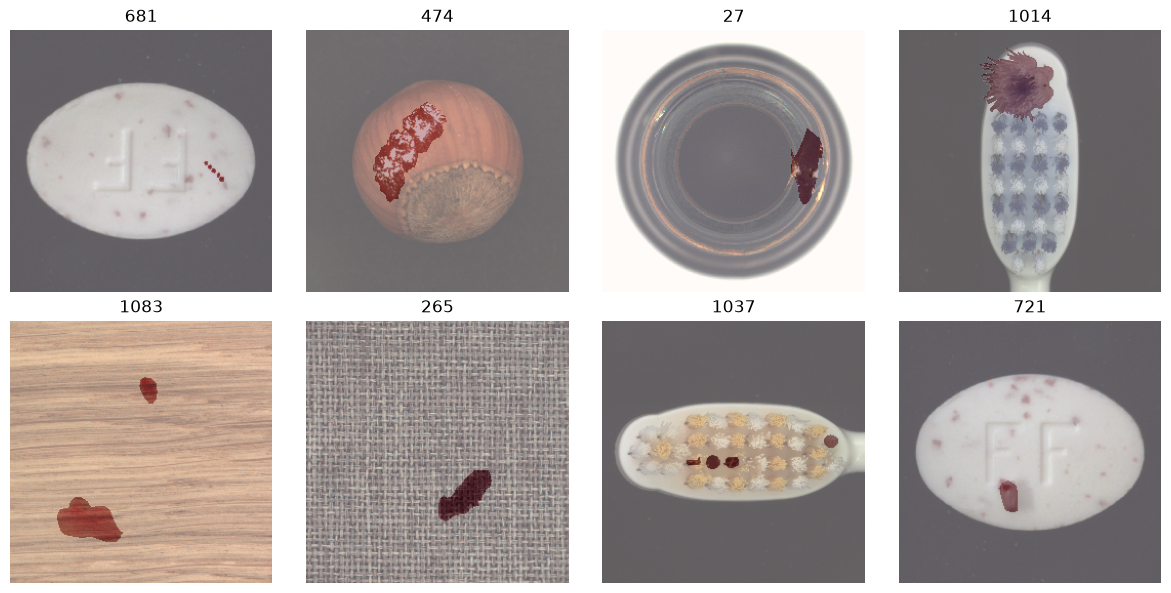

In [9]:
images = batch["image"][:8]
masks = batch["mask"][:8]

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.ravel()

for i in range(8):
    image = denormalize(images[i]).permute(1, 2, 0).numpy()
    mask = masks[i, 0].numpy()

    axes[i].imshow(image)
    axes[i].imshow(mask, cmap="Reds", alpha=0.35)
    axes[i].set_title(batch["image_id"][i])
    axes[i].axis("off")

plt.tight_layout()
plt.show()


## 11. Quantify mask sparsity in a batch


In [10]:
batch_mask_fraction = batch["mask"].mean(dim=(1, 2, 3))

print("Defect fraction per image in this batch:")
print(batch_mask_fraction.numpy())

print("\nMean defect fraction in batch:", batch_mask_fraction.mean().item())
print("Minimum:", batch_mask_fraction.min().item())
print("Maximum:", batch_mask_fraction.max().item())


Defect fraction per image in this batch:
[0.00123596 0.048172   0.02090454 0.04849243 0.0327301  0.02073669
 0.00738525 0.00657654 0.02108765 0.01509094 0.00650024 0.02944946
 0.04052734 0.00708008 0.00233459 0.0075531 ]

Mean defect fraction in batch: 0.019741058349609375
Minimum: 0.0012359619140625
Maximum: 0.048492431640625


## 12. Verify validation/test preprocessing is deterministic


In [11]:
a = val_dataset[0]
b = val_dataset[0]

print("Same image tensor:", torch.equal(a["image"], b["image"]))
print("Same mask tensor:", torch.equal(a["mask"], b["mask"]))
print("Same ID:", a["image_id"] == b["image_id"])

assert torch.equal(a["image"], b["image"])
assert torch.equal(a["mask"], b["mask"])


Same image tensor: True
Same mask tensor: True
Same ID: True


## 13. Preprocessing decisions

At this point we have:

**Input**
- RGB image
- 256×256

**Target**
- Binary segmentation mask
- 0 = background
- 1 = defect

**Training augmentation**
- Horizontal flip
- Vertical flip
- 90° rotations

**Validation/test**
- No random augmentation

**Normalization**
- ImageNet mean/std for compatibility with pretrained CNN backbones

The next notebook will train the **first segmentation baseline** and establish our initial Dice/IoU benchmark.
